In [1]:
!pip install tensorflow
!pip install scikit-learn
!pip install matplotlib
!pip install keras
!pip install keras_tuner
!pip install gzip
!pip install numpy
!pip install ViennaRNA
!pip install regex
!pip install seaborn
!pip install tensorboard

ERROR: Could not find a version that satisfies the requirement gzip (from versions: none)
ERROR: No matching distribution found for gzip


In [1]:
import gzip
import pandas as pd
import numpy as np
import sklearn
import regex as re
import seaborn as sns
import keras as ks
import keras_tuner as kt
import tensorflow
import csv
import regex as re
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score, classification_report, roc_curve, auc, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input, GlobalMaxPooling1D
from tensorflow.keras.metrics import Precision, Recall, F1Score
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

2026-06-18 11:04:55.625876: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# simple_hairpin = ["","...(((...)))...",
# "...((((...))))...",
# "...(((((...)))))...",
# "...((((((...))))))...",
# "...(((((((....)))))))...",
# "...((((((((....))))))))...",
# "...(((((((((....)))))))))...",
# "...((((((((((.....))))))))))...",
# "...(((((((((((.......)))))))))))...",
# "...((((((((((((........))))))))))))...",
# "...(((((((((((((........)))))))))))))...",
# "...((((((((((((((........))))))))))))))..."]

# simple_bulgeloop = ["","...((..(...)))...",
# "...((..((...))))...",
# "...(((..((...)))))...",
# "...(((..(((...))))))...",
# "...((((...(((....)))))))...",
# "...((((...((((....))))))))...",
# "...(((((...((((....)))))))))...",
# "...(((((....(((((.....))))))))))...",
# "...((((((.....(((((.......)))))))))))...",
# "...((((((......((((((........))))))))))))...",
# "...(((((((......((((((........)))))))))))))...",
# "...(((((((......(((((((........))))))))))))))..."]

# repetitive_short_hairpins = ["","...(((...)))...",
# "...(((...)))...(((...)))...",
# "...(((...)))...(((...)))...(((...)))...",
# "...(((...)))...(((...)))...(((...)))...(((...)))...",
# "...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...",
# "...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...",
# "...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...",
# "...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...",
# "...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...",
# "...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...",
# "...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...",
# "...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))..."]

# Define flexible regex motif families for real RNAfold-derived dot-bracket structures.
motif_patterns = {
    "hairpin": re.compile(r"\.{3,}\({3,}\.{3,}\){3,}\.{3,}"),
    "bulgeloop": re.compile(r"\.{3,}\({2,}\.{2,}\({1,}\.{3,}\){3,}\.{3,}"),
    "repetitive_hairpin_pattern":re.compile(r"(?:\.{3,}\({3}\.{3}\){3}\.{3,}){2,}")
}



In [3]:
# chars = [".", ")", "("]

# def insert_motif(background, motif):
#     x = list(background)
#     motif_len = len(motif)

#     idx = np.random.randint(0, len(x) - motif_len + 1)

#     x[idx:idx + motif_len] = list(motif)

#     return "".join(x), idx

# def shuffle_sequence(seq):
#     chars = list(seq)
#     np.random.shuffle(chars)
#     return "".join(chars)


In [4]:
# n_per_motif = 500

# n_total_positive = len(simple_hairpin) * n_per_motif

# # M1: 1000 negatives
# data_M1 = []

# for _ in range(n_total_positive):
#     seq = "".join(np.random.choice(chars, size=500, replace=True))
#     data_M1.append(seq)

# M1 = pd.DataFrame(data_M1, columns=["sequence"])
# M1["label"] = 0

# M2_base = M1.copy()
# M2_base["sequence"] = M2_base["sequence"].apply(shuffle_sequence)

# new_sequences = []
# motifs = []
# motif_starts = []

# row_idx = 0

# for motif in simple_hairpin:
#     for _ in range(n_per_motif):
#         background = M2_base.iloc[row_idx]["sequence"]

#         new_seq, idx = insert_motif(background, motif)

#         new_sequences.append(new_seq)
#         motifs.append(motif)
#         motif_starts.append(idx)

#         row_idx += 1

# M2 = pd.DataFrame({
#     "sequence": new_sequences,
#     "label": 1,
#     "motif": motifs,
#     "motif_start": motif_starts
# })

# M = pd.concat([M1, M2], ignore_index=True)

# print(M["label"].value_counts())
# print(M2["motif"].value_counts())
# print(M[1000:])

In [6]:
def one_hot_encode(seq, fixlength=500):
    if len(seq) < fixlength:
        seq += "." * (fixlength - len(seq))

    seq = seq[:fixlength]

    mapping = {
        "(": [1, 0, 0],
        ".": [0, 1, 0],
        ")": [0, 0, 1]
    }

    return np.array([mapping[base] for base in seq])

In [6]:
# def stem_length(structure):
#     return structure.count("(")

# def paired_length(structure):
#     return min(structure.count("("),structure.count(")"))

# def loop_length(structure):
#     loops = re.findall(r"\.+", structure)
#     if loops:
#         return max(len(loop) for loop in loops)
#     return 0

# def paired_ratio(structure):
#     paired = structure.count("(") + structure.count(")")
#     return paired / len(structure)

# def max_depth(structure):
#     depth = 0
#     max_d = 0

#     for char in structure:

#         if char == "(":
#             depth += 1
#             max_d = max(max_d, depth)

#         elif char == ")":
#             depth -= 1

#     return max_d

# def bulge_count(structure):
#     return structure.count("..")

# def stem_count(structure):
#     stems = re.findall(r"\(+", structure)
#     return len(stems)



In [ ]:
df = pd.read_csv('ViSiR_GenbankVirus_26.03_1000_selection.tsv', sep='\t', header=0)
print(df.shape)
print(df)

(20589, 19)
        accession  length    taxid                  host lab_host host_type  \
0        X62493.1    4789    12142                   NaN      NaN   unknown   
1        X16568.1    9207    11234                   NaN      NaN   unknown   
2        X16949.1    2309    28877                   NaN      NaN   unknown   
3        X56019.1    8101    12127                   NaN      NaN   unknown   
4        X02986.1    4003    11986                   NaN      NaN   unknown   
...           ...     ...      ...                   ...      ...       ...   
20584  PX597326.1    7728  2651944         Culex pipiens      NaN   natural   
20585  OZ412855.1   12714   162145                   NaN      NaN   unknown   
20586  BR002566.1    8269  2794431      Persea americana      NaN   natural   
20587  BR002569.1    8276   129141          Prunus avium      NaN   natural   
20588  BR002572.1    8264  2765862  Rhododendron obtusum      NaN   natural   

                 collection_date  \
0  

In [8]:
# # balanced_df = (
# #     df
# #     .groupby("Lineage4", group_keys=False)
# #     .apply(lambda x: x.sample(n=1000, random_state=42))
# #     .reset_index(drop=True)
# # )
# # Remove rows missing essential variables
# df_model = df.dropna(subset=["Lineage4", "fold"]).copy()

# # Find the smallest lineage
# minimum_lineage_size = df_model["Lineage4"].value_counts().min()

# print("Original lineage sizes:")
# print(df_model["Lineage4"].value_counts())

# print("\nMinimum lineage size:", minimum_lineage_size)

# # Sample the same number from every lineage
# balanced_df = (
#     df_model
#     .groupby("Lineage4", group_keys=False)
#     .sample(
#         n=minimum_lineage_size,
#         random_state=42
#     )
#     .reset_index(drop=True)
# )

# # Add a stable sequence identifier before splitting
# balanced_df["sequence_id"] = np.arange(len(balanced_df))

# print("\nBalanced lineage sizes:")
# print(balanced_df["Lineage4"].value_counts())

# balanced_df.to_pickle("balanced_lineage_dataset.pkl")


In [4]:
balanced_df = pd.read_pickle("balanced_lineage_dataset.pkl")

In [7]:
from sklearn.preprocessing import LabelEncoder

balanced_df["encoded_fold"] = balanced_df["fold"].apply(one_hot_encode, fixlength=1000)

X = np.array(list(balanced_df["encoded_fold"].values))

le = LabelEncoder()
y = le.fit_transform(balanced_df["Lineage4"].values)

num_classes = len(le.classes_)

In [11]:
print(df["Lineage4"].value_counts().sort_index())

Lineage4
Duplornaviricota    3249
Kitrinoviricota     4177
Lenarviricota       3055
Negarnaviricota     2492
Pisuviricota        7616
Name: count, dtype: int64


In [11]:
def stem_length(structure):
    return structure.count("(")

def paired_length(structure):
    """
    Return the number of paired positions in a motif.
    For dot-bracket motifs, this is the minimum of opening and closing brackets.
    """
    return min(structure.count("("),structure.count(")"))

def loop_length(structure):
    loops = re.findall(r"\.+", structure)
    if loops:
        return max(len(loop) for loop in loops)
    return 0

def paired_ratio(structure):
    paired = structure.count("(") + structure.count(")")
    return paired / len(structure)

def max_depth(structure):
    depth = 0
    max_d = 0

    for char in structure:

        if char == "(":
            depth += 1
            max_d = max(max_d, depth)

        elif char == ")":
            depth -= 1

    return max_d

def bulge_count(structure):
    count = 0

    for match in re.finditer(r"\.+", structure):
        start, end = match.span()

        left_part = structure[:start]
        right_part = structure[end:]

        has_left_pair = "(" in left_part
        has_right_pair = ")" in right_part

        if has_left_pair and has_right_pair:
            count += 1

    return count

def stem_count(structure):
    stems = re.findall(r"\(+", structure)
    return len(stems)

def repetitive_count(structure):
    """
    Count repeated hairpin-like units inside a detected structure.
    This is used as an additional descriptive feature for motif occurrences.
    """
    unit = "(((...)))"
    return structure.count(unit)

def count_motif(sequence, motif):
    return sequence.count(motif)

In [12]:
def build_model(hp):
    model = Sequential([
        Conv1D(
            filters = hp.Choice("filter_1", [16, 32, 64, 128]),
            kernel_size = hp.Choice("kernel_1", [3, 5, 8, 12]),
            activation = 'relu',
            input_shape = (1000,3)
        ),
        MaxPooling1D(
            pool_size = hp.Choice("pool_size_1", [2,3,4])        
        ),
        Conv1D(
            filters = hp.Choice("filter_2", [16, 32, 64, 128]),
            kernel_size = hp.Choice("kernel_2", [3, 5, 8, 12]),
            activation = 'relu'
        ),
        MaxPooling1D(
            pool_size = hp.Choice("pool_size_2", [2,3,4])        
        ),
        Flatten(),
        Dense(
            units = hp.Choice("units_1", [16, 32, 64, 128]),
            activation='relu'
        ),
        Dropout(
            rate = hp.Choice("rate", [0.3, 0.5])
        ),
        Dense(
            num_classes, 
            activation="softmax"
        )
        
    ])
    
    model.compile(
        optimizer = Adam(
            learning_rate = hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])
        ),
        loss = "sparse_categorical_crossentropy",# niet meer binary
        metrics=[
            'accuracy'
            
        ]
    )
    
    return model



In [ ]:
def build_fixed_model(num_classes):

    sequence_input = Input(shape=(1000, 3), name="sequence_input")

    x = Conv1D(32, kernel_size=8, activation="relu")(sequence_input)
    x = MaxPooling1D(pool_size=2)(x)

    x = Conv1D(64, kernel_size=8, activation="relu")(x)
    x = GlobalMaxPooling1D()(x)

    z = Dense(64, activation="relu")(x)
    z = Dropout(0.4)(z)

    output = Dense(num_classes, activation="softmax")(z)

    model = Model(inputs=sequence_input, outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [14]:
import shutil

shutil.rmtree("tuner_results/ViSiR_global_tuning", ignore_errors=True)


In [15]:
# all_motifs = (
#     simple_hairpin
#     + simple_bulgeloop
#     + repetitive_short_hairpins
# )

# motif_types = (
#     ["simple_hairpin"] * len(simple_hairpin)
#     + ["simple_bulgeloop"] * len(simple_bulgeloop)
#     + ["repetitive_short_hairpin"] * len(repetitive_short_hairpins)
# )

# motif_info = pd.DataFrame({
#     "motif_id": [f"motif_{i}" for i in range(len(all_motifs))],
#     "motif": all_motifs,
#     "motif_type": motif_types,
#     "paired_length": [paired_length(motif) for motif in all_motifs],
#     "sequence_length": [len(motif) for motif in all_motifs],
# })

In [16]:
# X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )

# tuner = kt.RandomSearch(
#     build_model,
#     objective="val_loss",
#     max_trials=5,
#     overwrite=True,
#     directory="tuner_results",
#     project_name="hairpin_global_tuning"
# )

# tuner.search(
#     X_train_all,
#     y_train_all,
#     epochs=10,
#     validation_split=0.2
# )

# best_hp = tuner.get_best_hyperparameters(1)[0]

# print("Best hyperparameters:")
# print(best_hp.values)

In [17]:
# df["simple_hairpin_count"] = df["fold"].apply(
#     lambda x: count_motifs_in_sequence(x, simple_hairpin)
# )

# df["bulgeloop_count"] = df["fold"].apply(
#     lambda x: count_motifs_in_sequence(x, simple_bulgeloop)
# )

# df["repetitive_hairpin_count"] = df["fold"].apply(
#     lambda x: count_motifs_in_sequence(x, repetitive_short_hairpins)
# )


# df["paired_length"] = df["fold"].apply(paired_length)
# df["paired_ratio"] = df["fold"].apply(paired_ratio)
# df["max_depth"] = df["fold"].apply(max_depth)
# df["stem_count"] = df["fold"].apply(stem_count)
# df["loop_length"] = df["fold"].apply(loop_length)


In [ ]:
def find_regex_motifs_in_sequence(fold):
    """
    Detect all regex-defined motifs in one dot-bracket sequence.

    Output:
    one dictionary per motif occurrence, including motif type, position,
    length, paired length, and repetition count.
    """
    occurrences = []

    for motif_type, pattern in motif_patterns.items():
        for match in pattern.finditer(fold):
            motif = match.group(0)

            occurrences.append({
                "motif_type": motif_type,
                "motif": motif,
                "motif_start": match.start(),
                "motif_end": match.end(),
                "paired_length": paired_length(motif),
                "sequence_length": len(motif),
                "repetitive_count": repetitive_count(motif)
            })

    return sorted(occurrences, key=lambda x: x["motif_start"])

In [ ]:
def motif_context_vector_regex(fold, sequence_length=1000, n_regions=5):
    occurrences = find_regex_motifs_in_sequence(fold)

    feature_dict = {}

    motif_type_names = ["hairpin", "bulgeloop", "repetitive_hairpin"]
    
    # Region-level motif counts
    for motif_type in motif_type_names:
        for region in range(1, n_regions + 1):
            feature_dict[f"{motif_type}_region_{region}"] = 0
            
    # Global motif-context features
    feature_dict["total_motif_count"] = 0
    feature_dict["mean_paired_length"] = 0
    feature_dict["max_paired_length"] = 0
    feature_dict["mean_motif_length"] = 0
    feature_dict["motif_transition_count"] = 0

    paired_lengths = []
    motif_lengths = []

    for occ in occurrences:
        region = int(occ["motif_start"] // (sequence_length / n_regions)) + 1
        region = min(region, n_regions)

        feature_dict[f"{occ['motif_type']}_region_{region}"] += 1
        feature_dict["total_motif_count"] += 1

        paired_lengths.append(occ["paired_length"])
        motif_lengths.append(occ["sequence_length"])

    # A transition is defined as a change from one detected motif occurrence
    # to the next motif occurrence in the same sequence.
    feature_dict["motif_transition_count"] = max(len(occurrences) - 1, 0)

    if paired_lengths:
        feature_dict["mean_paired_length"] = np.mean(paired_lengths)
        feature_dict["max_paired_length"] = np.max(paired_lengths)

    if motif_lengths:
        feature_dict["mean_motif_length"] = np.mean(motif_lengths)

    return feature_dict

In [ ]:
def evaluate_classification_plots(test_df, le, model_name):
    labels = list(le.classes_)

    # Classification report
    report = classification_report(
        test_df["true_lineage"],
        test_df["predicted_lineage"],
        output_dict=True,
        zero_division=0
    )

    per_class_report = (
        pd.DataFrame(report)
        .T
        .reset_index()
        .rename(columns={"index": "lineage"})
    )

    per_class_report = per_class_report[
        per_class_report["lineage"].isin(labels)
    ]

    metrics_long = per_class_report.melt(
        id_vars="lineage",
        value_vars=["precision", "recall", "f1-score"],
        var_name="metric",
        value_name="score"
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=metrics_long,
        x="lineage",
        y="score",
        hue="metric"
    )
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Lineage")
    plt.ylabel("Score")
    plt.title(f"Per-lineage classification performance: {model_name}")
    plt.tight_layout()
    plt.savefig(f"{model_name}_per_lineage_precision_recall_f1.png", dpi=300, bbox_inches="tight")
    plt.show()

    # True vs predicted distribution
    true_counts = (
        test_df["true_lineage"]
        .value_counts()
        .rename_axis("lineage")
        .reset_index(name="count")
    )
    true_counts["type"] = "True"

    pred_counts = (
        test_df["predicted_lineage"]
        .value_counts()
        .rename_axis("lineage")
        .reset_index(name="count")
    )
    pred_counts["type"] = "Predicted"

    distribution_df = pd.concat([true_counts, pred_counts], ignore_index=True)

    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=distribution_df,
        x="lineage",
        y="count",
        hue="type"
    )
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Lineage")
    plt.ylabel("Number of sequences")
    plt.title(f"True vs predicted lineage distribution: {model_name}")
    plt.tight_layout()
    plt.savefig(f"{model_name}_true_vs_predicted_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Prediction bias ratio
    bias_df = true_counts.merge(
        pred_counts,
        on="lineage",
        suffixes=("_true", "_predicted")
    )

    bias_df["prediction_bias_ratio"] = (
        bias_df["count_predicted"] / bias_df["count_true"]
    )

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=bias_df,
        x="lineage",
        y="prediction_bias_ratio"
    )
    plt.axhline(1, linestyle="--")
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Lineage")
    plt.ylabel("Predicted / true count")
    plt.title(f"Prediction bias ratio: {model_name}")
    plt.tight_layout()
    plt.savefig(f"{model_name}_prediction_bias_ratio.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Normalized confusion matrix by true label
    cm_true = confusion_matrix(
        test_df["true_lineage"],
        test_df["predicted_lineage"],
        labels=labels,
        normalize="true"
    )

    plt.figure(figsize=(8, 7))
    sns.heatmap(
        cm_true,
        annot=True,
        fmt=".2f",
        xticklabels=labels,
        yticklabels=labels,
        cmap="Blues"
    )
    plt.xlabel("Predicted lineage")
    plt.ylabel("True lineage")
    plt.title(f"Confusion matrix normalized by true lineage: {model_name}")
    plt.tight_layout()
    plt.savefig(f"{model_name}_confusion_matrix_true_normalized.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Normalized confusion matrix by predicted label
    cm = confusion_matrix(
        test_df["true_lineage"],
        test_df["predicted_lineage"],
        labels=labels
    )

    cm_pred = cm / cm.sum(axis=0, keepdims=True)
    cm_pred = np.nan_to_num(cm_pred)

    plt.figure(figsize=(8, 7))
    sns.heatmap(
        cm_pred,
        annot=True,
        fmt=".2f",
        xticklabels=labels,
        yticklabels=labels,
        cmap="Blues"
    )
    plt.xlabel("Predicted lineage")
    plt.ylabel("True lineage")
    plt.title(f"Confusion matrix normalized by predicted lineage: {model_name}")
    plt.tight_layout()
    plt.savefig(f"{model_name}_confusion_matrix_predicted_normalized.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Most common misclassifications
    errors_df = test_df[
        test_df["true_lineage"] != test_df["predicted_lineage"]
    ].copy()

    error_pairs = (
        errors_df
        .groupby(["true_lineage", "predicted_lineage"])
        .size()
        .reset_index(name="n_errors")
        .sort_values("n_errors", ascending=False)
    )

    error_pairs["error_pair"] = (
        error_pairs["true_lineage"] + " → " + error_pairs["predicted_lineage"]
    )

    top_errors = error_pairs.head(15)

    plt.figure(figsize=(9, 6))
    sns.barplot(
        data=top_errors,
        y="error_pair",
        x="n_errors"
    )
    plt.xlabel("Number of errors")
    plt.ylabel("Misclassification")
    plt.title(f"Most common lineage misclassifications: {model_name}")
    plt.tight_layout()
    plt.savefig(f"{model_name}_most_common_misclassifications.png", dpi=300, bbox_inches="tight")
    plt.show()

    return per_class_report, bias_df, error_pairs

In [21]:
results_regex = []
motif_regex_results = []
prediction_regex_outputs = []
motif_occurrence_outputs = []

for seed in range(3):

    train_df, test_df = train_test_split(
        balanced_df,
        test_size=0.2,
        random_state=seed,
        stratify=balanced_df["Lineage4"]
    )

    X_train = np.array(list(train_df["encoded_fold"].values)).astype("float32")
    X_test = np.array(list(test_df["encoded_fold"].values)).astype("float32")

    y_train = le.transform(train_df["Lineage4"].values)
    y_test = le.transform(test_df["Lineage4"].values)

    model = build_fixed_model(5)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=30,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )

    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

    macro_precision = precision_score(
        y_test, y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_test, y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_test, y_pred,
        average="macro",
        zero_division=0
    )

    weighted_precision = precision_score(
        y_test, y_pred,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        y_test, y_pred,
        average="weighted",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_test, y_pred,
        average="weighted",
        zero_division=0
    )

    test_df = test_df.copy()

    test_df["seed"] = seed
    test_df["y_true"] = y_test
    test_df["y_pred"] = y_pred
    test_df["true_lineage"] = le.inverse_transform(y_test)
    test_df["predicted_lineage"] = le.inverse_transform(y_pred)
    test_df["correct"] = (y_test == y_pred).astype(int)
    test_df["prediction_confidence"] = y_pred_prob.max(axis=1)
    
    for class_index, class_name in enumerate(le.classes_):
        test_df[f"prob_{class_name}"] = y_pred_prob[:, class_index]

    prediction_regex_outputs.append(test_df)
    
    # Save overall model performance for this seed
    results_regex.append({
        "seed": seed,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "epochs_trained": len(history.history["loss"]),
        "best_val_loss": min(history.history["val_loss"]),
        "best_val_accuracy": max(history.history["val_accuracy"])
    })

    # Motif-level post-hoc analysis
    for motif_type, pattern in motif_patterns.items():

        test_df[f"{motif_type}_present"] = test_df["fold"].apply(
            lambda x: int(pattern.search(x) is not None)
        )

        motif_present_df = test_df[test_df[f"{motif_type}_present"] == 1]
        motif_absent_df = test_df[test_df[f"{motif_type}_present"] == 0]

        motif_regex_results.append({
            "seed": seed,
            "motif_type": motif_type,
            "n_present": len(motif_present_df),
            "n_absent": len(motif_absent_df),
            "motif_presence_rate": test_df[f"{motif_type}_present"].mean(),
            "accuracy_when_present": (
                motif_present_df["correct"].mean()
                if len(motif_present_df) > 0 else np.nan
            ),
            "accuracy_when_absent": (
                motif_absent_df["correct"].mean()
                if len(motif_absent_df) > 0 else np.nan
            ),
            "accuracy_difference": (
                (motif_present_df["correct"].mean() if len(motif_present_df) > 0 else np.nan)
                - (motif_absent_df["correct"].mean() if len(motif_absent_df) > 0 else np.nan)
            )
        })

    # Occurrence-level motif data for motif-transition analysis
    for row_idx, row in test_df.iterrows():
        occurrences = find_regex_motifs_in_sequence(row["fold"])

        for motif_order, occ in enumerate(occurrences):
            motif_occurrence_outputs.append({
                "seed": seed,
                "row_index": row_idx,
                "true_lineage": row["true_lineage"],
                "predicted_lineage": row["predicted_lineage"],
                "correct": row["correct"],
                "prediction_confidence": row["prediction_confidence"],
                "motif_order": motif_order,
                **occ
            })

2026-06-17 11:14:14.777914: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/30


2026-06-17 11:14:15.160221: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 95688000 exceeds 10% of free system memory.


250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 68ms/step - accuracy: 0.2016 - loss: 1.6232 - val_accuracy: 0.2598 - val_loss: 1.6021
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.2627 - loss: 1.5996 - val_accuracy: 0.3255 - val_loss: 1.5876
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.2870 - loss: 1.5843 - val_accuracy: 0.3320 - val_loss: 1.5681
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.3269 - loss: 1.5544 - val_accuracy: 0.3375 - val_loss: 1.5280
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - accuracy: 0.3216 - loss: 1.5140 - val_accuracy: 0.3335 - val_loss: 1.4860
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - accuracy: 0.3369 - loss: 1.4733 - val_accuracy: 0.3355 - val_loss: 1.4626
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.3422 - loss: 1.4530 - val_accuracy: 0.3501 - val_loss: 1.4459
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.3517 - loss: 1.4474 - val_accuracy: 0.

2026-06-17 11:18:51.347848: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 95688000 exceeds 10% of free system memory.


250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.1928 - loss: 1.6340 - val_accuracy: 0.2347 - val_loss: 1.5971
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.2551 - loss: 1.5904 - val_accuracy: 0.3265 - val_loss: 1.5662
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.3122 - loss: 1.5452 - val_accuracy: 0.3430 - val_loss: 1.5114
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.3245 - loss: 1.5008 - val_accuracy: 0.3340 - val_loss: 1.4764
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.3347 - loss: 1.4693 - val_accuracy: 0.3450 - val_loss: 1.4581
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.3513 - loss: 1.4427 - val_accuracy: 0.3526 - val_loss: 1.4443
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.3635 - loss: 1.4298 - val_accuracy: 0.3566 - val_loss: 1.4334
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.3549 - loss: 1.4191 - val_accuracy: 0.357

2026-06-17 11:22:10.185775: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 95688000 exceeds 10% of free system memory.


250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.2120 - loss: 1.6275 - val_accuracy: 0.3144 - val_loss: 1.5988
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.2379 - loss: 1.6008 - val_accuracy: 0.3119 - val_loss: 1.5832
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.2854 - loss: 1.5804 - val_accuracy: 0.3240 - val_loss: 1.5476
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.3037 - loss: 1.5463 - val_accuracy: 0.3245 - val_loss: 1.5018
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.3265 - loss: 1.5000 - val_accuracy: 0.3485 - val_loss: 1.4592
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.3410 - loss: 1.4713 - val_accuracy: 0.3711 - val_loss: 1.4310
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.3317 - loss: 1.4497 - val_accuracy: 0.3666 - val_loss: 1.4137
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.3531 - loss: 1.4370 - val_accuracy: 0.366

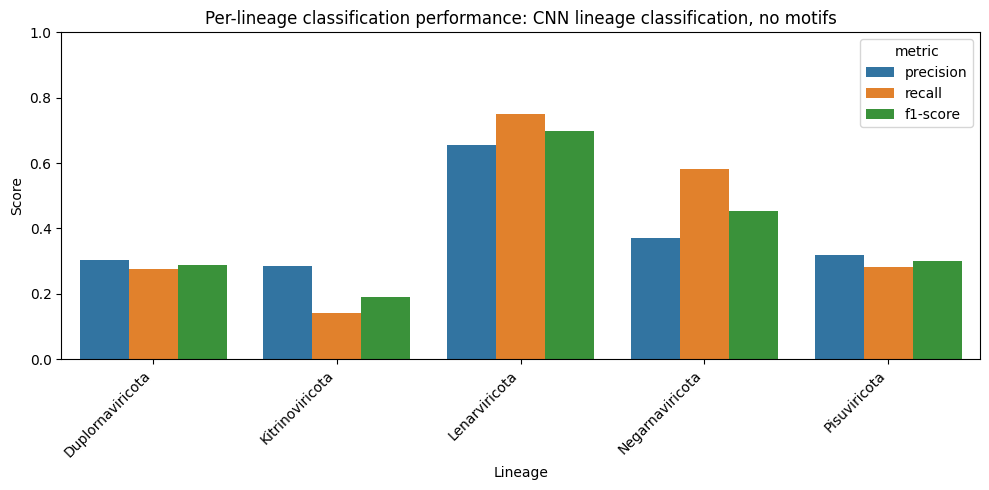

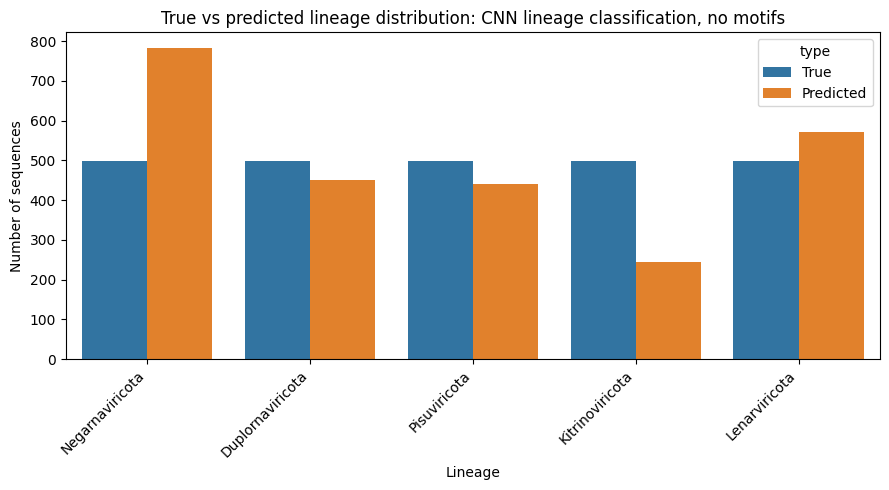

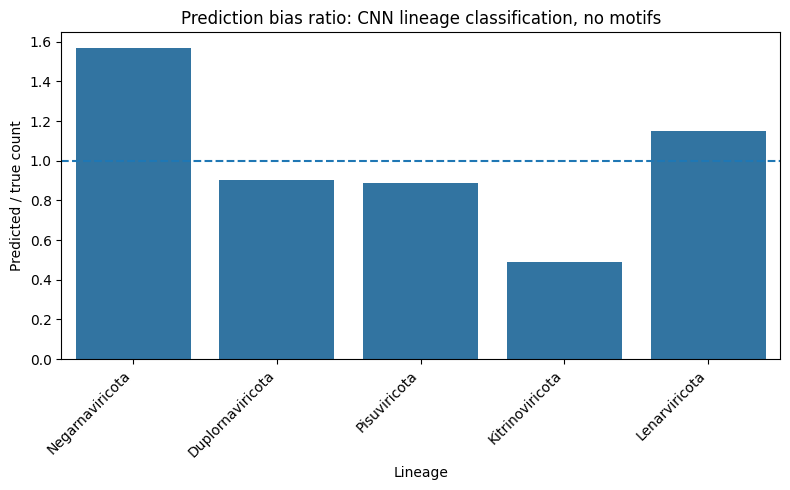

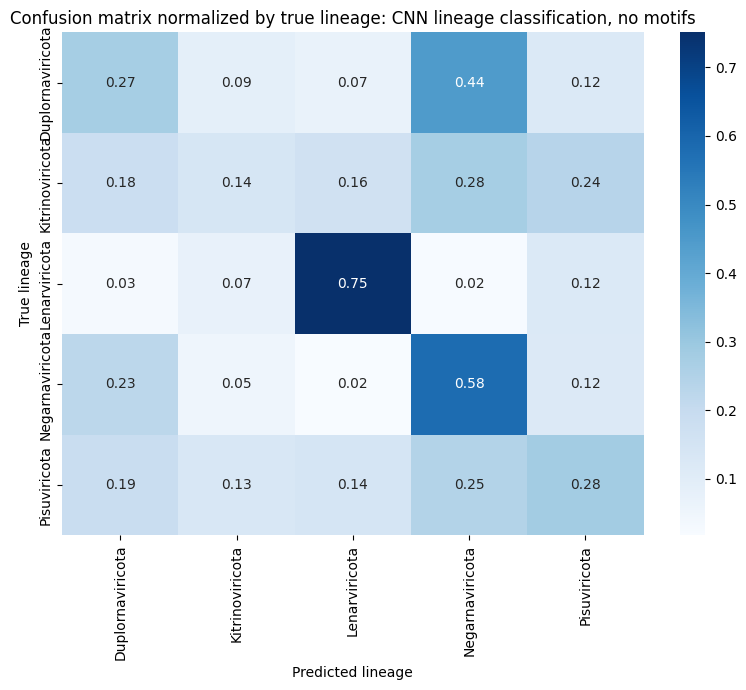

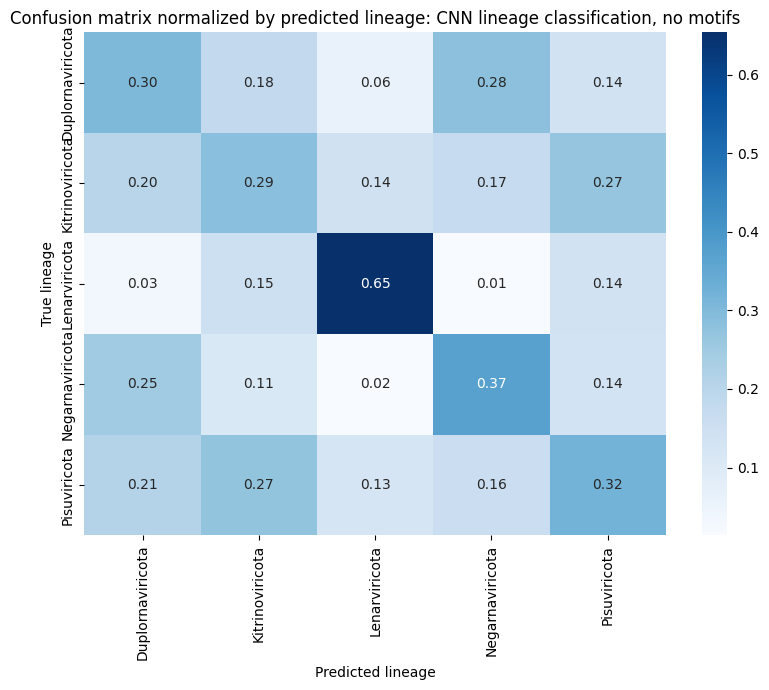

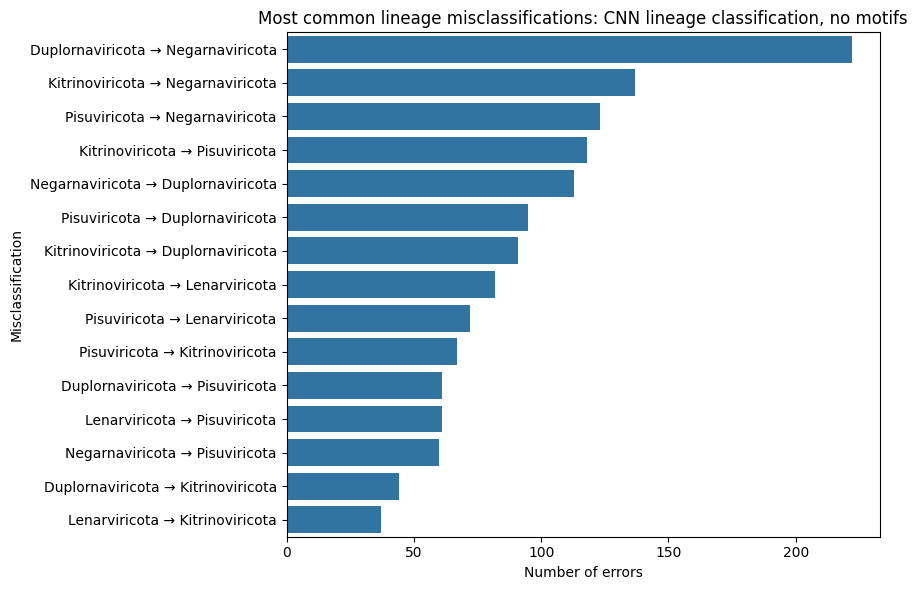

(            lineage  precision    recall  f1-score  support
 0  Duplornaviricota   0.303769  0.274549  0.288421    499.0
 1   Kitrinoviricota   0.285714  0.140562  0.188425    498.0
 2     Lenarviricota   0.653846  0.751004  0.699065    498.0
 3   Negarnaviricota   0.370370  0.581162  0.452418    499.0
 4      Pisuviricota   0.319728  0.283133  0.300319    498.0,
             lineage  count_true type_true  count_predicted type_predicted  \
 0   Negarnaviricota         499      True              783      Predicted   
 1  Duplornaviricota         499      True              451      Predicted   
 2      Pisuviricota         498      True              441      Predicted   
 3   Kitrinoviricota         498      True              245      Predicted   
 4     Lenarviricota         498      True              572      Predicted   
 
    prediction_bias_ratio  
 0               1.569138  
 1               0.903808  
 2               0.885542  
 3               0.491968  
 4               1.1485

In [22]:
evaluate_classification_plots(test_df, le, "CNN lineage classification, no motifs")

In [23]:
# bias_df = true_counts.merge(
#     pred_counts,
#     on="lineage",
#     suffixes=("_true", "_predicted")
# )

# bias_df["prediction_bias_ratio"] = (
#     bias_df["count_predicted"] / bias_df["count_true"]
# )

# print(bias_df)

In [24]:
results_regex_df = pd.DataFrame(results_regex)
motif_regex_results_df = pd.DataFrame(motif_regex_results)
prediction_regex_outputs_df = pd.concat(prediction_regex_outputs, ignore_index=True)
motif_occurrence_regex_df = pd.DataFrame(motif_occurrence_outputs)

results_regex_df.to_csv("cnn_only_regex_lineage_metrics.csv", index=False)
motif_regex_results_df.to_csv("cnn_only_regex_motif_effects.csv", index=False)
prediction_regex_outputs_df.to_csv("cnn_only_regex_predictions.csv", index=False)
motif_occurrence_regex_df.to_csv("cnn_only_regex_motif_occurrences.csv", index=False)

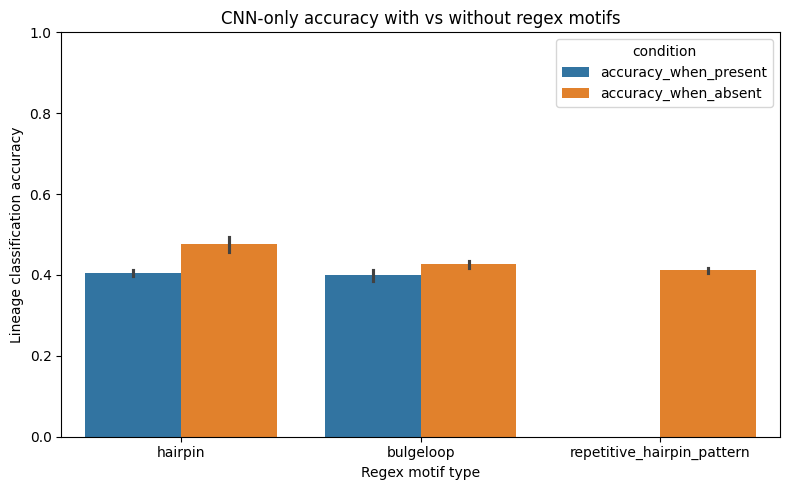

In [25]:
plot_regex_df = motif_regex_results_df.melt(
    id_vars=["seed", "motif_type", "n_present", "n_absent", "motif_presence_rate"],
    value_vars=["accuracy_when_present", "accuracy_when_absent"],
    var_name="condition",
    value_name="accuracy"
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=plot_regex_df,
    x="motif_type",
    y="accuracy",
    hue="condition",
    errorbar="sd"
)

plt.ylim(0, 1)
plt.xlabel("Regex motif type")
plt.ylabel("Lineage classification accuracy")
plt.title("CNN-only accuracy with vs without regex motifs")
plt.tight_layout()
plt.savefig("cnn_only_regex_accuracy_present_vs_absent.png", dpi=300, bbox_inches="tight")
plt.show()

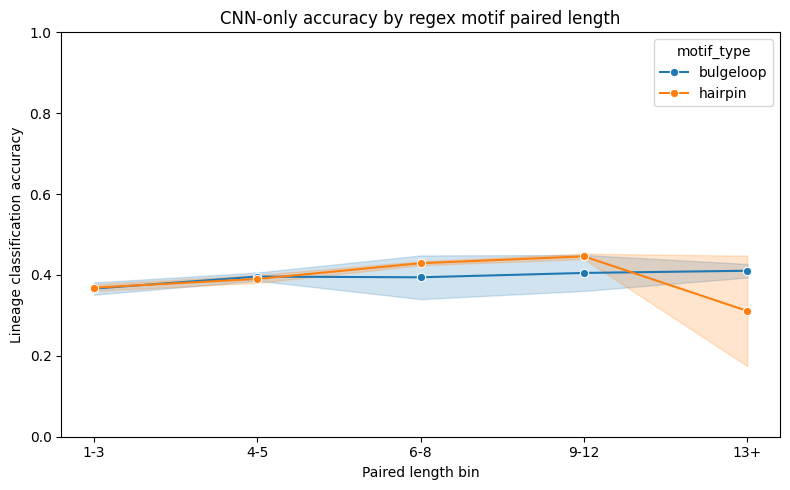

In [26]:
motif_occurrence_regex_df["paired_length_bin"] = pd.cut(
    motif_occurrence_regex_df["paired_length"],
    bins=[0, 3, 5, 8, 12, 25],
    labels=["1-3", "4-5", "6-8", "9-12", "13+"]
)

paired_length_accuracy = (
    motif_occurrence_regex_df
    .groupby(["seed", "motif_type", "paired_length_bin"], observed=False)
    .agg(
        accuracy=("correct", "mean"),
        n_occurrences=("correct", "size")
    )
    .reset_index()
)

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=paired_length_accuracy,
    x="paired_length_bin",
    y="accuracy",
    hue="motif_type",
    marker="o",
    errorbar="sd"
)

plt.ylim(0, 1)
plt.xlabel("Paired length bin")
plt.ylabel("Lineage classification accuracy")
plt.title("CNN-only accuracy by regex motif paired length")
plt.tight_layout()
plt.savefig("cnn_only_regex_accuracy_by_paired_length.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
prediction_regex_outputs_df = pd.concat(
    prediction_regex_outputs,
    ignore_index=True
)

# Add regex motif-context features per sequence
motif_features_per_sequence = pd.DataFrame(
    list(prediction_regex_outputs_df["fold"].apply(motif_context_vector_regex))
)

prediction_regex_outputs_with_motifs_df = pd.concat(
    [
        prediction_regex_outputs_df.reset_index(drop=True),
        motif_features_per_sequence.reset_index(drop=True)
    ],
    axis=1
)

prediction_regex_outputs_with_motifs_df.to_csv(
    "cnn_only_regex_predictions_with_motif_features.csv",
    index=False
)

wrong_df = prediction_regex_outputs_with_motifs_df[
    prediction_regex_outputs_with_motifs_df["correct"] == 0
].copy()

wrong_df.to_csv("cnn_only_wrongly_classified_sequences.csv", index=False)

print(wrong_df.shape)
print(wrong_df[["true_lineage", "predicted_lineage", "prediction_confidence"]].head())

wrong_df["error_type"] = (
    wrong_df["true_lineage"] + " → " + wrong_df["predicted_lineage"]
)

error_counts = (
    wrong_df["error_type"]
    .value_counts()
    .reset_index()
)

error_counts.columns = ["error_type", "n_errors"]

print(error_counts.head(20))

error_counts.to_csv("cnn_only_common_error_types.csv", index=False)

(4400, 56)
       true_lineage predicted_lineage  prediction_confidence
2   Negarnaviricota      Pisuviricota               0.308767
3  Duplornaviricota   Negarnaviricota               0.285508
5      Pisuviricota  Duplornaviricota               0.287782
6  Duplornaviricota   Negarnaviricota               0.307329
9      Pisuviricota   Negarnaviricota               0.310175
                            error_type  n_errors
0   Duplornaviricota → Negarnaviricota       632
1       Pisuviricota → Negarnaviricota       389
2    Kitrinoviricota → Negarnaviricota       381
3       Kitrinoviricota → Pisuviricota       301
4   Negarnaviricota → Duplornaviricota       288
5      Kitrinoviricota → Lenarviricota       275
6       Pisuviricota → Kitrinoviricota       267
7   Kitrinoviricota → Duplornaviricota       245
8         Pisuviricota → Lenarviricota       231
9      Pisuviricota → Duplornaviricota       231
10     Duplornaviricota → Pisuviricota       194
11      Negarnaviricota → Pisuviric

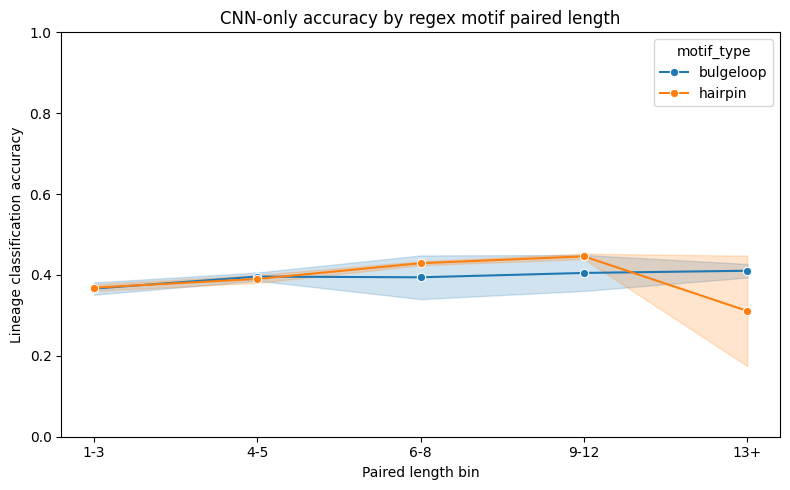

In [28]:
motif_occurrence_regex_df["paired_length_bin"] = pd.cut(
    motif_occurrence_regex_df["paired_length"],
    bins=[0, 3, 5, 8, 12, 25],
    labels=["1-3", "4-5", "6-8", "9-12", "13+"]
)

paired_length_accuracy = (
    motif_occurrence_regex_df
    .groupby(["seed", "motif_type", "paired_length_bin"], observed=False)
    .agg(
        accuracy=("correct", "mean"),
        n_occurrences=("correct", "size")
    )
    .reset_index()
)

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=paired_length_accuracy,
    x="paired_length_bin",
    y="accuracy",
    hue="motif_type",
    marker="o",
    errorbar="sd"
)

plt.ylim(0, 1)
plt.xlabel("Paired length bin")
plt.ylabel("Lineage classification accuracy")
plt.title("CNN-only accuracy by regex motif paired length")
plt.tight_layout()
plt.savefig("cnn_only_regex_accuracy_by_paired_length.png", dpi=300, bbox_inches="tight")
plt.show()

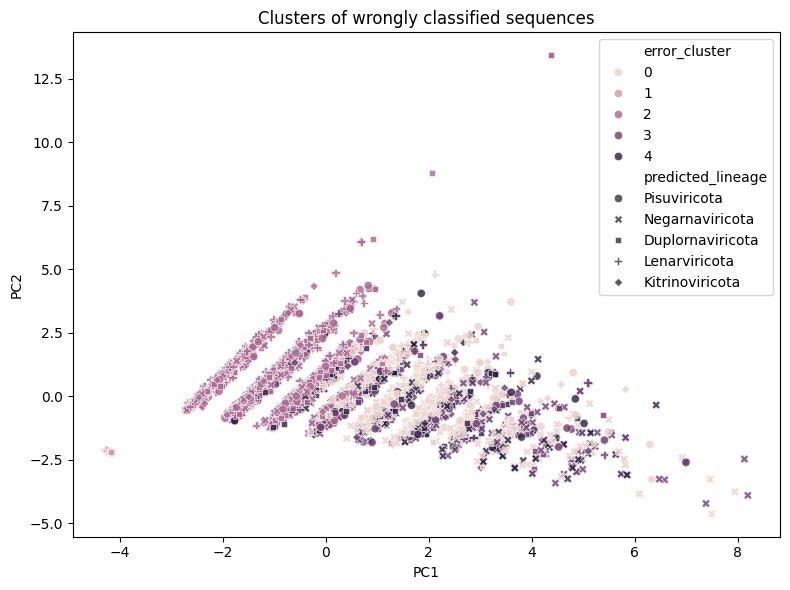

   error_cluster  n_sequences  mean_confidence  mean_total_motif_count  \
0              0          965         0.322525                5.447668   
1              1          319         0.356471                0.009404   
2              2         2129         0.329415                2.214655   
3              3          462         0.324075                5.727273   
4              4          525         0.325492                5.059048   

   mean_paired_length  mean_max_paired_length  mean_transition_count  
0            5.247590                7.690155               4.447668  
1            0.028213                0.028213               0.000000  
2            5.124479                5.991076               1.214655  
3            5.238996                7.653680               4.727273  
4            5.218661                7.209524               4.059048  
    error_cluster                          error_type  n_errors
2               0  Duplornaviricota → Negarnaviricota       163
6

In [29]:
feature_cols = [
    col for col in wrong_df.columns
    if (
        "region" in col
        or col in [
            "total_motif_count",
            "mean_paired_length",
            "max_paired_length",
            "mean_motif_length",
            "motif_transition_count",
            "prediction_confidence"
        ]
    )
]

X_wrong = wrong_df[feature_cols].fillna(0).values

scaler = StandardScaler()
X_wrong_scaled = scaler.fit_transform(X_wrong)

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

wrong_df["error_cluster"] = kmeans.fit_predict(X_wrong_scaled)

wrong_df.to_csv(
    "cnn_only_wrongly_classified_sequences_clustered.csv",
    index=False
)

pca = PCA(n_components=2, random_state=42)
X_wrong_pca = pca.fit_transform(X_wrong_scaled)

wrong_df["PC1"] = X_wrong_pca[:, 0]
wrong_df["PC2"] = X_wrong_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=wrong_df,
    x="PC1",
    y="PC2",
    hue="error_cluster",
    style="predicted_lineage",
    alpha=0.8
)

plt.title("Clusters of wrongly classified sequences")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("cnn_only_wrong_sequences_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

cluster_summary = (
    wrong_df
    .groupby("error_cluster")
    .agg(
        n_sequences=("correct", "size"),
        mean_confidence=("prediction_confidence", "mean"),
        mean_total_motif_count=("total_motif_count", "mean"),
        mean_paired_length=("mean_paired_length", "mean"),
        mean_max_paired_length=("max_paired_length", "mean"),
        mean_transition_count=("motif_transition_count", "mean")
    )
    .reset_index()
)

print(cluster_summary)

cluster_summary.to_csv(
    "cnn_only_wrong_sequence_cluster_summary.csv",
    index=False
)

cluster_error_types = (
    wrong_df
    .groupby(["error_cluster", "error_type"])
    .size()
    .reset_index(name="n_errors")
    .sort_values(["error_cluster", "n_errors"], ascending=[True, False])
)

print(cluster_error_types.head(30))

cluster_error_types.to_csv(
    "cnn_only_cluster_error_types.csv",
    index=False
)

In [30]:
explained_variance = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance_ratio": pca.explained_variance_ratio_
})

print(explained_variance)

  component  explained_variance_ratio
0       PC1                  0.268293
1       PC2                  0.106128


In [31]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=["PC1_loading", "PC2_loading"]
)

print(
    pca_loadings
    .sort_values("PC1_loading", key=abs, ascending=False)
    .head(10)
)

print(
    pca_loadings
    .sort_values("PC2_loading", key=abs, ascending=False)
    .head(10)
)

pca_loadings.to_csv("pca_feature_loadings_wrong_sequences.csv")

                        PC1_loading  PC2_loading
total_motif_count          0.460715    -0.222751
motif_transition_count     0.449156    -0.274827
max_paired_length          0.332654     0.468758
mean_paired_length         0.251886     0.605953
hairpin_region_1           0.222998    -0.062054
mean_motif_length          0.221693     0.439791
hairpin_region_2           0.207097    -0.093592
hairpin_region_4           0.206881    -0.115173
hairpin_region_3           0.206068    -0.099518
bulgeloop_region_1         0.194278    -0.087811
                        PC1_loading  PC2_loading
mean_paired_length         0.251886     0.605953
max_paired_length          0.332654     0.468758
mean_motif_length          0.221693     0.439791
motif_transition_count     0.449156    -0.274827
total_motif_count          0.460715    -0.222751
hairpin_region_4           0.206881    -0.115173
bulgeloop_region_4         0.165277    -0.115031
bulgeloop_region_3         0.166026    -0.111272
hairpin_region_3    

In [32]:
cnn_only_predictions_df = pd.concat(
    prediction_regex_outputs,
    ignore_index=True
)

motif_features_per_sequence = pd.DataFrame(
    list(
        cnn_only_predictions_df["fold"].apply(
            motif_context_vector_regex
        )
    )
)

cnn_only_predictions_with_features_df = pd.concat(
    [
        cnn_only_predictions_df.reset_index(drop=True),
        motif_features_per_sequence.reset_index(drop=True)
    ],
    axis=1
)

positive_df = cnn_only_predictions_with_features_df[
    cnn_only_predictions_with_features_df["correct"] == 1
].copy()

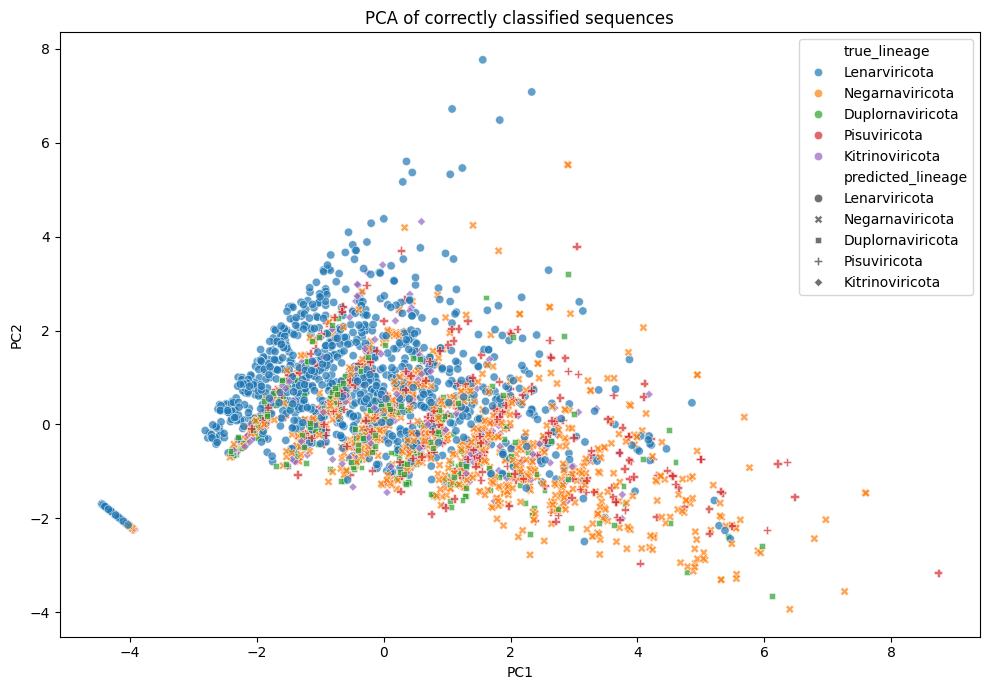

                              PC1_loading   PC2_loading
prediction_confidence       -1.534123e-01  1.656046e-01
hairpin_region_1             2.353426e-01 -1.555530e-01
hairpin_region_2             2.044935e-01 -1.932383e-02
hairpin_region_3             2.002142e-01 -8.871823e-02
hairpin_region_4             2.206501e-01 -1.302188e-01
hairpin_region_5             1.993199e-01 -1.119533e-01
bulgeloop_region_1           1.979446e-01 -1.606894e-01
bulgeloop_region_2           1.526648e-01  8.173438e-03
bulgeloop_region_3           1.534227e-01 -9.609644e-02
bulgeloop_region_4           1.426513e-01 -9.918701e-02
bulgeloop_region_5           1.290220e-01 -8.003781e-02
repetitive_hairpin_region_1 -0.000000e+00  0.000000e+00
repetitive_hairpin_region_2 -0.000000e+00  1.694066e-21
repetitive_hairpin_region_3 -0.000000e+00  0.000000e+00
repetitive_hairpin_region_4 -7.703720e-34  0.000000e+00
repetitive_hairpin_region_5 -0.000000e+00  0.000000e+00
total_motif_count            4.351577e-01 -2.193

In [33]:
feature_cols = [
    col for col in positive_df.columns
    if (
        "region" in col
        or col in [
            "total_motif_count",
            "mean_paired_length",
            "max_paired_length",
            "mean_motif_length",
            "motif_transition_count",
            "prediction_confidence"
        ]
    )
]

X_positive = positive_df[feature_cols].fillna(0).values

scaler = StandardScaler()
X_positive_scaled = scaler.fit_transform(X_positive)

pca = PCA(n_components=2, random_state=42)
X_positive_pca = pca.fit_transform(X_positive_scaled)

positive_df["PC1"] = X_positive_pca[:, 0]
positive_df["PC2"] = X_positive_pca[:, 1]

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=positive_df,
    x="PC1",
    y="PC2",
    hue="true_lineage",
    style="predicted_lineage",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of correctly classified sequences")

plt.tight_layout()
plt.savefig(
    "cnn_only_correctly_classified_sequences_pca.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

positive_df.to_csv(
    "cnn_only_correctly_classified_sequences_pca.csv",
    index=False
)

pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=["PC1_loading", "PC2_loading"]
)

print(pca_loadings)

explained_variance = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance_ratio": pca.explained_variance_ratio_
})

print(explained_variance)

In [ ]:
def create_prediction_pca(
    prediction_list,
    correct_value,
    model_name,
    output_prefix,
    add_clusters=False,
    n_clusters=5
):

    # Combine prediction results from all seeds

    predictions_df = pd.concat(
        prediction_list,
        ignore_index=True
    )

    # Calculate motif-context features per sequence

    motif_features_df = pd.DataFrame(
        list(
            predictions_df["fold"].apply(
                motif_context_vector_regex
            )
        )
    )

    predictions_with_features_df = pd.concat(
        [
            predictions_df.reset_index(drop=True),
            motif_features_df.reset_index(drop=True)
        ],
        axis=1
    )

    # Select correct or wrong predictions

    subset_df = predictions_with_features_df[
        predictions_with_features_df["correct"] == correct_value
    ].copy()

    classification_name = (
        "correctly classified"
        if correct_value == 1
        else "wrongly classified"
    )

    print(
        f"\n{model_name}: {classification_name} sequences:",
        len(subset_df)
    )

    print("\nSequences per true lineage:")
    print(
        subset_df["true_lineage"]
        .value_counts()
    )

    # Select the same structural features everywhere
  
    requested_feature_cols = [
        col for col in subset_df.columns
        if (
            col.startswith("hairpin_region_")
            or col.startswith("bulgeloop_region_")
            or col.startswith("repetitive_hairpin_region_")
            or col in [
                "total_motif_count",
                "mean_paired_length",
                "max_paired_length",
                "mean_motif_length",
                "motif_transition_count"
            ]
        )
    ]

    # Remove zero-variance columns

    zero_variance_cols = [
        col for col in requested_feature_cols
        if subset_df[col].nunique(dropna=False) <= 1
    ]

    feature_cols = [
        col for col in requested_feature_cols
        if col not in zero_variance_cols
    ]

    print("\nRemoved zero-variance features:")
    print(zero_variance_cols)

    print("\nFeatures used for PCA:")
    print(feature_cols)

    if len(feature_cols) < 2:
        raise ValueError(
            "Fewer than two non-constant features remain for PCA."
        )

    # Standardize features

    X_subset = (
        subset_df[feature_cols]
        .fillna(0)
        .values
    )

    scaler = StandardScaler()

    X_subset_scaled = scaler.fit_transform(
        X_subset
    )


    # Fit PCA

    pca = PCA(
        n_components=2,
        random_state=42
    )

    X_subset_pca = pca.fit_transform(
        X_subset_scaled
    )

    subset_df["PC1"] = X_subset_pca[:, 0]
    subset_df["PC2"] = X_subset_pca[:, 1]

    # Optionally cluster in original standardized space

    if add_clusters:
        kmeans = KMeans(
            n_clusters=n_clusters,
            random_state=42,
            n_init=20
        )

        subset_df["pca_cluster"] = kmeans.fit_predict(
            X_subset_scaled
        )


    # PCA loadings

    loadings_df = pd.DataFrame(
        pca.components_.T,
        index=feature_cols,
        columns=[
            "PC1_loading",
            "PC2_loading"
        ]
    )


    # Explained variance

    variance_df = pd.DataFrame({
        "component": ["PC1", "PC2"],
        "explained_variance_ratio":
            pca.explained_variance_ratio_
    })

    print("\nExplained variance:")
    print(variance_df)

    print("\nLargest absolute PC1 loadings:")
    print(
        loadings_df.loc[
            loadings_df["PC1_loading"]
            .abs()
            .sort_values(ascending=False)
            .index
        ].head(10)
    )

    print("\nLargest absolute PC2 loadings:")
    print(
        loadings_df.loc[
            loadings_df["PC2_loading"]
            .abs()
            .sort_values(ascending=False)
            .index
        ].head(10)
    )

    # Plot
    plt.figure(figsize=(10, 7))

    if add_clusters:
        sns.scatterplot(
            data=subset_df,
            x="PC1",
            y="PC2",
            hue="pca_cluster",
            style="true_lineage",
            palette="tab10",
            alpha=0.70,
            s=55
        )

        legend_title = "Cluster / true lineage"

    else:
        sns.scatterplot(
            data=subset_df,
            x="PC1",
            y="PC2",
            hue="true_lineage",
            style="true_lineage",
            alpha=0.70,
            s=55
        )

        legend_title = "True lineage"

    pc1_variance = (
        pca.explained_variance_ratio_[0] * 100
    )

    pc2_variance = (
        pca.explained_variance_ratio_[1] * 100
    )

    plt.xlabel(
        f"PC1 ({pc1_variance:.1f}% explained variance)"
    )

    plt.ylabel(
        f"PC2 ({pc2_variance:.1f}% explained variance)"
    )

    plt.title(
        f"{model_name}: PCA of {classification_name} sequences"
    )

    plt.legend(
        title=legend_title,
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.savefig(
        f"{output_prefix}_pca.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # Save outputs

    subset_df.to_csv(
        f"{output_prefix}_pca_sequences.csv",
        index=False
    )

    loadings_df.to_csv(
        f"{output_prefix}_pca_loadings.csv"
    )

    variance_df.to_csv(
        f"{output_prefix}_pca_variance.csv",
        index=False
    )

    return {
        "data": subset_df,
        "loadings": loadings_df,
        "variance": variance_df,
        "scaler": scaler,
        "pca": pca,
        "feature_cols": feature_cols
    }


CNN-only: wrongly classified sequences: 4400

Sequences per true lineage:
true_lineage
Kitrinoviricota     1202
Pisuviricota        1118
Duplornaviricota    1117
Negarnaviricota      633
Lenarviricota        330
Name: count, dtype: int64

Removed zero-variance features:
['repetitive_hairpin_region_1', 'repetitive_hairpin_region_2', 'repetitive_hairpin_region_3', 'repetitive_hairpin_region_4', 'repetitive_hairpin_region_5']

Features used for PCA:
['hairpin_region_1', 'hairpin_region_2', 'hairpin_region_3', 'hairpin_region_4', 'hairpin_region_5', 'bulgeloop_region_1', 'bulgeloop_region_2', 'bulgeloop_region_3', 'bulgeloop_region_4', 'bulgeloop_region_5', 'total_motif_count', 'mean_paired_length', 'max_paired_length', 'mean_motif_length', 'motif_transition_count']

Explained variance:
  component  explained_variance_ratio
0       PC1                  0.286102
1       PC2                  0.113191

Largest absolute PC1 loadings:
                        PC1_loading  PC2_loading
total_moti

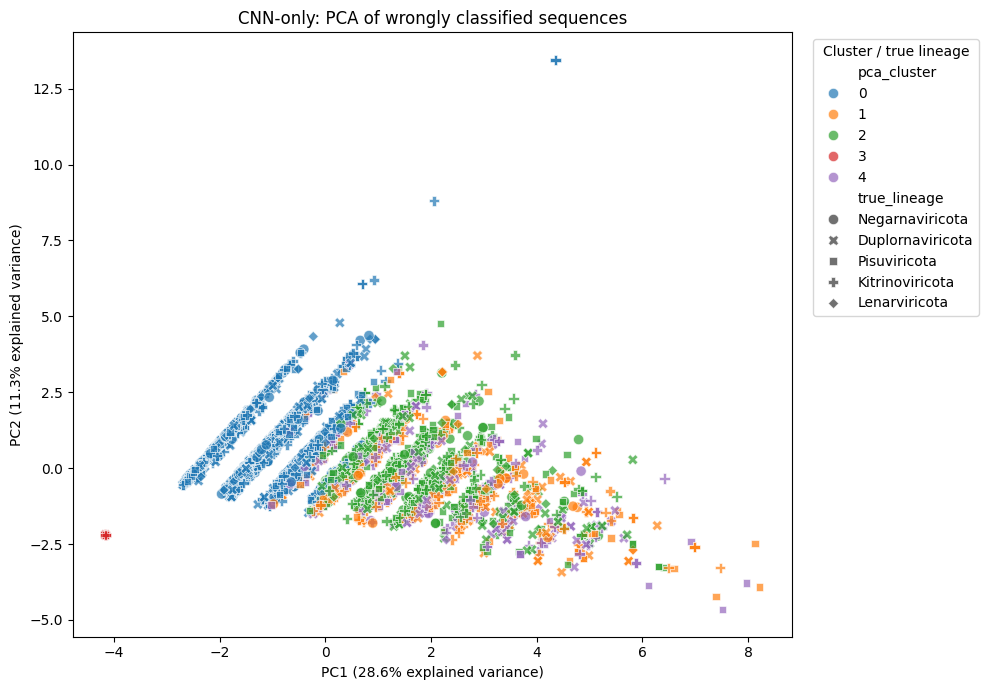

In [36]:
cnn_only_wrong_pca = create_prediction_pca(
    prediction_list=prediction_regex_outputs,
    correct_value=0,
    model_name="CNN-only",
    output_prefix="cnn_only_wrong",
    add_clusters=True,
    n_clusters=5
)

cnn_only_wrong_df = cnn_only_wrong_pca["data"]

cnn_only_wrong_df["pca_cluster"]

cnn_only_wrong_df = cnn_only_wrong_df.rename(
    columns={"pca_cluster": "error_cluster"}
)

In [1]:
def plot_top_pca_loadings(
    loadings_df,
    output_prefix,
    model_name,
    classification_name,
    top_n=10
):

    required_columns = {
        "PC1_loading",
        "PC2_loading"
    }

    missing_columns = required_columns.difference(
        loadings_df.columns
    )

    if missing_columns:
        raise ValueError(
            f"Missing loading columns: {missing_columns}"
        )

    # Make sure feature names are available as a column
    loading_plot_df = (
        loadings_df
        .reset_index()
        .rename(columns={"index": "feature"})
    )

    for component in ["PC1", "PC2"]:

        loading_column = f"{component}_loading"

        # Select largest features by absolute loading
        top_loadings = (
            loading_plot_df
            .assign(
                absolute_loading=lambda df:
                    df[loading_column].abs()
            )
            .sort_values(
                "absolute_loading",
                ascending=False
            )
            .head(top_n)
            .sort_values(
                loading_column,
                ascending=True
            )
        )

        print(
            f"\n{model_name}, {classification_name}: "
            f"largest {component} loadings"
        )

        print(
            top_loadings[
                [
                    "feature",
                    loading_column,
                    "absolute_loading"
                ]
            ]
        )

        # Save selected loadings
        top_loadings.to_csv(
            f"{output_prefix}_{component.lower()}_top_loadings.csv",
            index=False
        )

        # Plot signed loadings
        plt.figure(figsize=(9, 6))

        sns.barplot(
            data=top_loadings,
            x=loading_column,
            y="feature",
            orient="h"
        )

        plt.axvline(
            0,
            color="black",
            linewidth=1
        )

        plt.xlabel(f"{component} loading")
        plt.ylabel("Motif-context feature")

        plt.title(
            f"{model_name}: largest {component} loadings\n"
            f"{classification_name} sequences"
        )

        plt.tight_layout()

        plt.savefig(
            f"{output_prefix}_{component.lower()}_top_loadings.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()


CNN-only, correctly classified: largest PC1 loadings
                   feature  PC1_loading  absolute_loading
2         hairpin_region_3     0.200684          0.200684
5       bulgeloop_region_1     0.201444          0.201444
1         hairpin_region_2     0.207280          0.207280
3         hairpin_region_4     0.222068          0.222068
0         hairpin_region_1     0.238800          0.238800
11      mean_paired_length     0.250874          0.250874
13       mean_motif_length     0.319316          0.319316
12       max_paired_length     0.329300          0.329300
14  motif_transition_count     0.423833          0.423833
10       total_motif_count     0.438697          0.438697


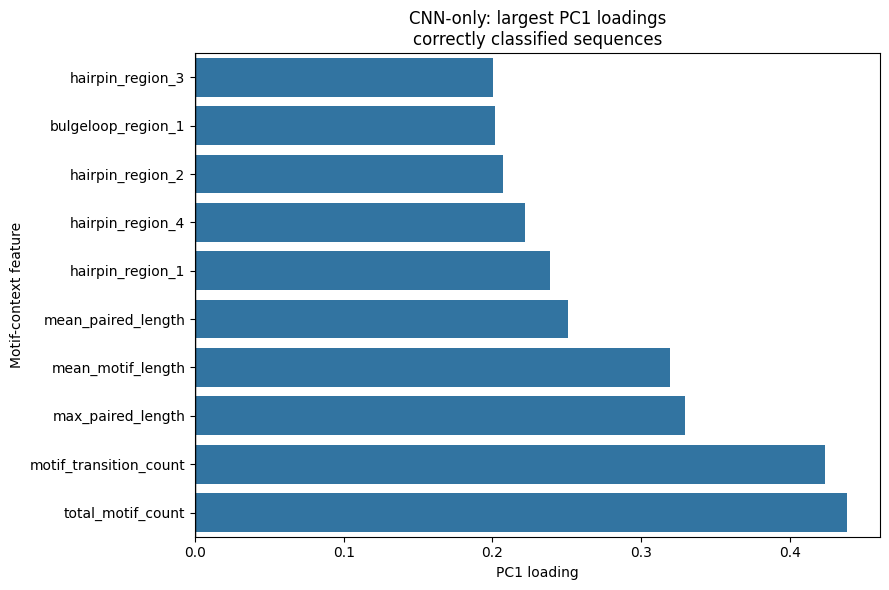


CNN-only, correctly classified: largest PC2 loadings
                   feature  PC2_loading  absolute_loading
14  motif_transition_count    -0.296992          0.296992
10       total_motif_count    -0.237185          0.237185
5       bulgeloop_region_1    -0.187962          0.187962
0         hairpin_region_1    -0.181950          0.181950
3         hairpin_region_4    -0.136731          0.136731
4         hairpin_region_5    -0.109086          0.109086
8       bulgeloop_region_4    -0.099606          0.099606
13       mean_motif_length     0.386346          0.386346
12       max_paired_length     0.458741          0.458741
11      mean_paired_length     0.603048          0.603048


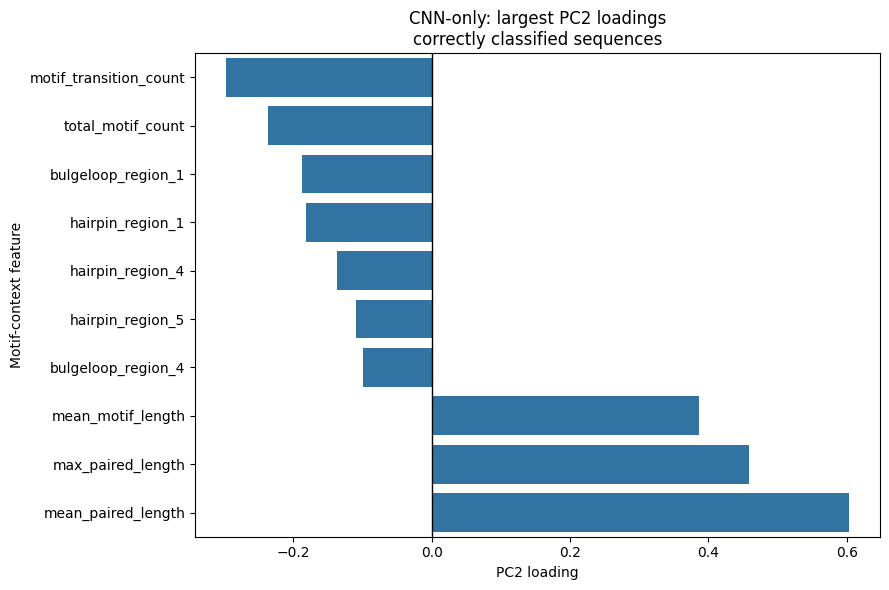


CNN-only, wrongly classified: largest PC1 loadings
                   feature  PC1_loading  absolute_loading
5       bulgeloop_region_1     0.194260          0.194260
2         hairpin_region_3     0.206149          0.206149
3         hairpin_region_4     0.206782          0.206782
1         hairpin_region_2     0.207148          0.207148
13       mean_motif_length     0.221609          0.221609
0         hairpin_region_1     0.222989          0.222989
11      mean_paired_length     0.252079          0.252079
12       max_paired_length     0.332777          0.332777
14  motif_transition_count     0.449233          0.449233
10       total_motif_count     0.460769          0.460769


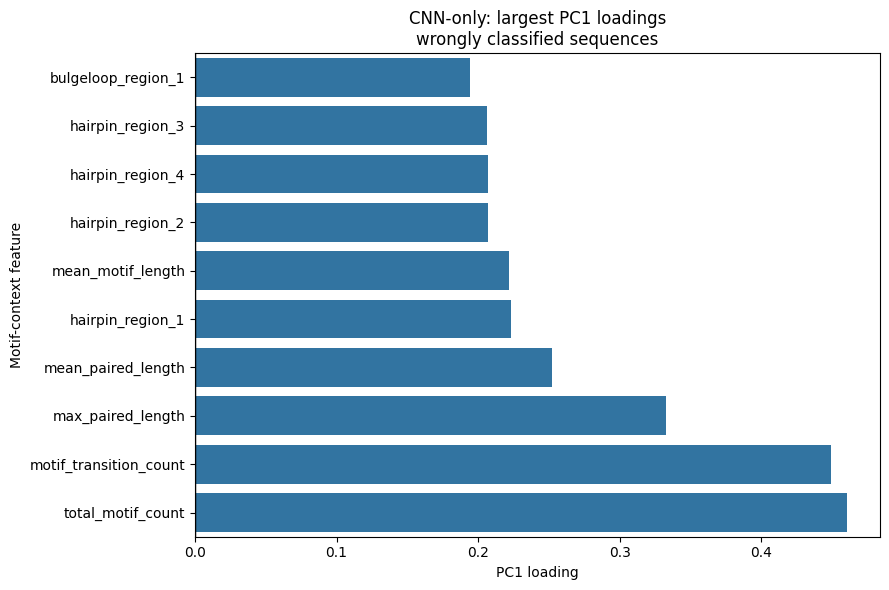


CNN-only, wrongly classified: largest PC2 loadings
                   feature  PC2_loading  absolute_loading
14  motif_transition_count    -0.275075          0.275075
10       total_motif_count    -0.222933          0.222933
8       bulgeloop_region_4    -0.114969          0.114969
3         hairpin_region_4    -0.114745          0.114745
7       bulgeloop_region_3    -0.111478          0.111478
2         hairpin_region_3    -0.099876          0.099876
9       bulgeloop_region_5    -0.099379          0.099379
13       mean_motif_length     0.440219          0.440219
12       max_paired_length     0.468580          0.468580
11      mean_paired_length     0.605674          0.605674


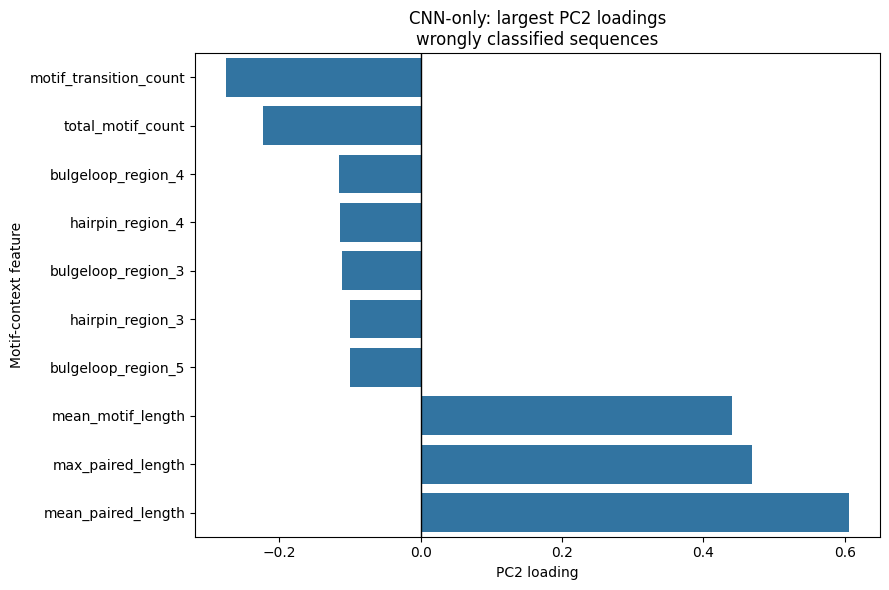

In [38]:
plot_top_pca_loadings(
    loadings_df=cnn_only_correct_pca["loadings"],
    output_prefix="cnn_only_correct",
    model_name="CNN-only",
    classification_name="correctly classified",
    top_n=10
)

plot_top_pca_loadings(
    loadings_df=cnn_only_wrong_pca["loadings"],
    output_prefix="cnn_only_wrong",
    model_name="CNN-only",
    classification_name="wrongly classified",
    top_n=10
)

In [39]:
def plot_multiclass_roc(
    prediction_outputs,
    classes,
    model_name,
    output_filename
):
    """
    Plot one-vs-rest ROC curves using predictions pooled across seeds.
    """

    predictions_df = pd.concat(
        prediction_outputs,
        ignore_index=True
    )

    classes = np.asarray(classes)
    n_classes = len(classes)

    probability_columns = [
        f"prob_{class_name}"
        for class_name in classes
    ]

    missing_columns = [
        column
        for column in probability_columns
        if column not in predictions_df.columns
    ]

    if missing_columns:
        raise ValueError(
            "Missing probability columns: "
            f"{missing_columns}. Rerun the prediction loop after "
            "saving every class probability."
        )

    y_true = predictions_df["y_true"].to_numpy()

    y_score = predictions_df[
        probability_columns
    ].to_numpy()

    # Convert multiclass labels into binary one-vs-rest columns
    y_true_binary = label_binarize(
        y_true,
        classes=np.arange(n_classes)
    )

    fpr = {}
    tpr = {}
    roc_auc = {}

    # ROC curve for each lineage
    for class_index, class_name in enumerate(classes):

        fpr[class_name], tpr[class_name], _ = roc_curve(
            y_true_binary[:, class_index],
            y_score[:, class_index]
        )

        roc_auc[class_name] = auc(
            fpr[class_name],
            tpr[class_name]
        )

    # Micro-average ROC
    fpr["micro"], tpr["micro"], _ = roc_curve(
        y_true_binary.ravel(),
        y_score.ravel()
    )

    roc_auc["micro"] = auc(
        fpr["micro"],
        tpr["micro"]
    )

    # Macro-average ROC curve
    all_fpr = np.unique(
        np.concatenate([
            fpr[class_name]
            for class_name in classes
        ])
    )

    mean_tpr = np.zeros_like(all_fpr)

    for class_name in classes:
        mean_tpr += np.interp(
            all_fpr,
            fpr[class_name],
            tpr[class_name]
        )

    mean_tpr /= n_classes

    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr

    roc_auc["macro"] = auc(
        fpr["macro"],
        tpr["macro"]
    )

    # Plot
    plt.figure(figsize=(10, 8))

    for class_name in classes:
        plt.plot(
            fpr[class_name],
            tpr[class_name],
            linewidth=2,
            label=(
                f"{class_name} "
                f"(AUC = {roc_auc[class_name]:.3f})"
            )
        )

    plt.plot(
        fpr["macro"],
        tpr["macro"],
        linestyle="--",
        linewidth=3,
        label=(
            "Macro-average "
            f"(AUC = {roc_auc['macro']:.3f})"
        )
    )

    plt.plot(
        fpr["micro"],
        tpr["micro"],
        linestyle=":",
        linewidth=3,
        label=(
            "Micro-average "
            f"(AUC = {roc_auc['micro']:.3f})"
        )
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
        label="Chance"
    )

    plt.xlim(0, 1)
    plt.ylim(0, 1.02)

    plt.xlabel("False-positive rate")
    plt.ylabel("True-positive rate")
    plt.title(f"One-vs-rest ROC curves: {model_name}")

    plt.legend(
        loc="lower right",
        fontsize=8
    )

    plt.tight_layout()

    plt.savefig(
        output_filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    auc_df = pd.DataFrame({
        "lineage": list(classes)
            + ["macro_average", "micro_average"],
        "roc_auc": [
            roc_auc[class_name]
            for class_name in classes
        ] + [
            roc_auc["macro"],
            roc_auc["micro"]
        ]
    })

    print(auc_df)

    return auc_df

In [40]:
def calculate_auc_by_seed(
    prediction_outputs,
    classes,
    model_name
):
    classes = np.asarray(classes)

    probability_columns = [
        f"prob_{class_name}"
        for class_name in classes
    ]

    auc_rows = []

    for seed_df in prediction_outputs:

        seed = seed_df["seed"].iloc[0]

        y_true = seed_df["y_true"].to_numpy()

        y_true_binary = label_binarize(
            y_true,
            classes=np.arange(len(classes))
        )

        y_score = seed_df[
            probability_columns
        ].to_numpy()

        macro_auc = roc_auc_score(
            y_true_binary,
            y_score,
            average="macro",
            multi_class="ovr"
        )

        weighted_auc = roc_auc_score(
            y_true_binary,
            y_score,
            average="weighted",
            multi_class="ovr"
        )

        micro_auc = roc_auc_score(
            y_true_binary,
            y_score,
            average="micro",
            multi_class="ovr"
        )

        auc_rows.append({
            "model": model_name,
            "seed": seed,
            "macro_auc": macro_auc,
            "weighted_auc": weighted_auc,
            "micro_auc": micro_auc
        })

    return pd.DataFrame(auc_rows)

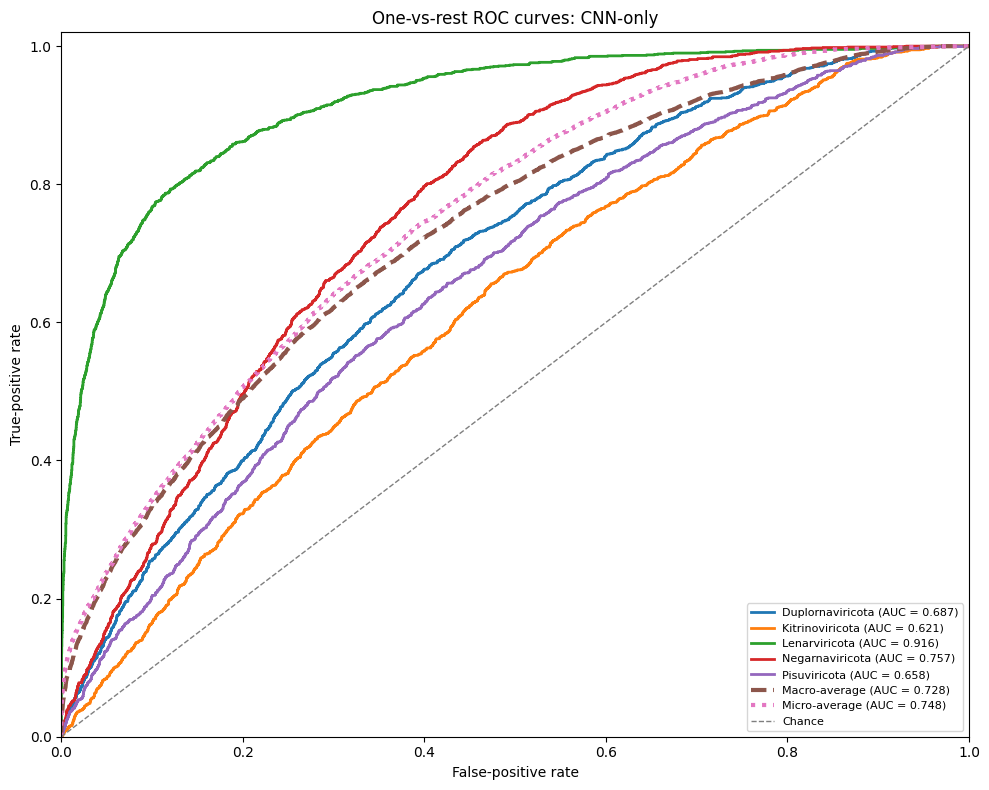

            lineage   roc_auc
0  Duplornaviricota  0.687394
1   Kitrinoviricota  0.620790
2     Lenarviricota  0.916464
3   Negarnaviricota  0.756997
4      Pisuviricota  0.658034
5     macro_average  0.728028
6     micro_average  0.748461


In [41]:
cnn_only_auc_df = plot_multiclass_roc(
    prediction_outputs=prediction_regex_outputs,
    classes=le.classes_,
    model_name="CNN-only",
    output_filename="cnn_only_multiclass_roc.png"
)